In [34]:
"""
Pull Google Trends search indices for three Fed/macro-anxiety terms at
US-national daily granularity and stitch overlapping windows into a
continuous normalised series.

Challenge:Google Trends returns DAILY data only for windows ≤ 270 days.
For longer windows it silently switches to WEEKLY aggregation.

Stitching strategy (overlap-anchor method):
  1.  Divide the full window into overlapping 90-day chunks
      (step = 60 days, overlap = 30 days on each side).
  2.  Pull daily data for each chunk.
  3.  In the overlap region, compute the ratio of the *new* series to the
      *anchor* series; multiply the new chunk by this ratio to align scales.
  4.  Concatenate, take the mean where overlaps remain, and re-normalise
      the full series to 0–100.
  5.  Save the final aligned daily DataFrame.

Fallback: if pytrends daily requests fail for a chunk (rate-limit or
Google server error), retry up to 3 times with exponential back-off,
then interpolate missing days from adjacent data.

Dependencies: pip install pytrends pandas
"""

import os
import time
import pandas as pd
from pytrends.request import TrendReq
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
TERM        = "gold price"
DATA_DIR    = Path("C:/Python/CSUREMM/test")          # your data directory
CHUNK_DAYS  = 269                         # ~9 months: max window pytrends gives daily data
STEP_DAYS   = 240                         # ~8 months step → ~29 days of overlap per seam
START_DATE  = pd.Timestamp("2022-01-01")
END_DATE    = pd.Timestamp("2026-05-31")
SLEEP_SEC   = 5                           # polite delay between API calls

# ── Helper: build a safe filename from a date window ─────────────────────────
def window_filename(start: pd.Timestamp, end: pd.Timestamp, prefix: str = "gt_daily") -> str:
    return f"{prefix}_{start.date()}_{end.date()}.csv"

In [35]:
# ── Step 1: Download overlapping daily chunks ─────────────────────────────────
def download_daily_chunks():
    """
    Pull overlapping 269-day windows from pytrends and save each as its own CSV.
    Skips windows already on disk so the script is safely re-runnable.
    """
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    pytrends = TrendReq(hl="en-US", tz=0, timeout=(10, 30), retries=3, backoff_factor=0.5)

    chunk_start = START_DATE
    downloaded  = 0
    skipped     = 0

    while chunk_start <= END_DATE:
        chunk_end = min(chunk_start + pd.Timedelta(days=CHUNK_DAYS - 1), END_DATE)
        fname     = DATA_DIR / window_filename(chunk_start, chunk_end)

        if fname.exists():
            print(f"  [skip] {chunk_start.date()} → {chunk_end.date()} (already on disk)")
            skipped += 1
        else:
            timeframe = f"{chunk_start.date()} {chunk_end.date()}"
            print(f"  [pull] {timeframe} …", end=" ", flush=True)
            try:
                pytrends.build_payload([TERM], cat=0, timeframe=timeframe, geo="US", gprop="")
                df = pytrends.interest_over_time()

                if df.empty or TERM not in df.columns:
                    print("empty — skipped")
                else:
                    out = df[[TERM]].reset_index().rename(columns={"date": "Time", TERM: "value"})
                    # Drop the isPartial flag row if pytrends appended it
                    out = out[["Time", "value"]]
                    out.to_csv(fname, index=False)
                    print(f"{len(out)} rows saved → {fname.name}")
                    downloaded += 1

            except Exception as e:
                print(f"ERROR: {e} — skipped")

        chunk_start += pd.Timedelta(days=STEP_DAYS)
        time.sleep(SLEEP_SEC)

    print(f"\nDownload complete: {downloaded} new, {skipped} skipped.")

In [36]:
# ── Step 2: Download the long-range monthly series for anchor calibration ─────
def download_monthly_anchor():
    """
    Pull a single multi-year monthly series from pytrends (pytrends returns
    weekly/monthly automatically for long timeframes).
    Saved as gt_monthly_<start>_<end>.csv.
    """
    fname = DATA_DIR / window_filename(START_DATE, END_DATE, prefix="gt_monthly")
    if fname.exists():
        print(f"[skip] monthly anchor already on disk: {fname.name}")
        return

    pytrends  = TrendReq(hl="en-US", tz=0, timeout=(10, 30), retries=3, backoff_factor=0.5)
    timeframe = f"{START_DATE.date()} {END_DATE.date()}"
    print(f"[pull] monthly anchor {timeframe} …", end=" ", flush=True)

    try:
        pytrends.build_payload([TERM], cat=0, timeframe=timeframe, geo="US", gprop="")
        df = pytrends.interest_over_time()

        if df.empty or TERM not in df.columns:
            print("empty — monthly anchor not saved")
            return

        out = df[[TERM]].reset_index().rename(columns={"date": "Time", TERM: "monthly_gt"})
        out = out[["Time", "monthly_gt"]]
        out.to_csv(fname, index=False)
        print(f"{len(out)} rows saved → {fname.name}")

    except Exception as e:
        print(f"ERROR downloading monthly anchor: {e}")

In [37]:
# ── Step 3: Detect & classify downloaded files ────────────────────────────────
def classify_files():
    """
    Returns (daily_files, monthly_file) by inspecting median date gap —
    exactly Plan B's detection logic.
    """
    all_files    = [f for f in DATA_DIR.iterdir() if f.suffix == ".csv"]
    daily_files  = []
    monthly_file = None

    for f in all_files:
        df     = pd.read_csv(f)
        col    = "Time" if "Time" in df.columns else df.columns[0]
        dates  = pd.to_datetime(df[col])
        median_gap = dates.diff().dt.days.median()

        if median_gap <= 2:          # daily cadence
            daily_files.append(f)
        else:                        # weekly or monthly cadence
            monthly_file = f

    daily_files = sorted(daily_files, key=lambda f: pd.read_csv(f)["Time"].min())
    print(f"Detected {len(daily_files)} daily files, monthly anchor: "
          f"{monthly_file.name if monthly_file else 'None'}")
    return daily_files, monthly_file

In [38]:
# ── Step 4: Stitch daily chunks (median ratio, weekdays-only overlap) ─────────
def stitch_daily(daily_files: list) -> pd.DataFrame:
    """
    Median-ratio stitching on overlap dates.
    Overlap zone is averaged (not dropped) for smoother seams.
    Requires >= 5 weekday overlap points for a reliable ratio.
    """
    dfs = []
    for f in daily_files:
        df            = pd.read_csv(f, parse_dates=["Time"])
        df            = df.rename(columns={c: "value" for c in df.columns if c != "Time"})
        df            = df.sort_values("Time").drop_duplicates("Time")
        dfs.append(df)

    if not dfs:
        raise ValueError("No daily files to stitch.")

    stitched = dfs[0].copy()

    for i in range(1, len(dfs)):
        prev = stitched
        curr = dfs[i].copy()

        # Overlap on weekdays only — consistent with final stock-market join
        overlap = prev.merge(curr, on="Time", suffixes=("_prev", "_curr"))
        # overlap = overlap[overlap["Time"].dt.dayofweek < 5]   # Mon–Fri only

        if len(overlap) >= 5:
            # Median ratio: robust to event spikes in the overlap window
            median_prev = overlap["value_prev"].median()
            median_curr = overlap["value_curr"].median()
            scale = median_prev / median_curr if median_curr > 1e-9 else 1.0
        else:
            print(f"  WARNING: only {len(overlap)} weekday overlap points for chunk {i} "
                  f"— using scale=1.0 fallback")
            scale = 1.0

        curr = curr.copy()
        curr["value"] *= scale

        # Average the overlap zone instead of hard-cutting, for smoother seams
        combined = pd.concat([prev, curr]).groupby("Time", as_index=False)["value"].mean()
        stitched = combined.sort_values("Time").reset_index(drop=True)

    return stitched

In [39]:
# ── Step 5: Monthly anchor calibration, local rolling average ───────────────────────────────────────
def apply_monthly_anchor_local(stitched: pd.DataFrame, monthly_file) -> pd.DataFrame:
    """
    Instead of one global scale factor, compute a rolling monthly correction
    and interpolate it daily — handles structural breaks like the 2026 surge.
    """
    monthly = pd.read_csv(monthly_file, parse_dates=["Time"]).set_index("Time").squeeze()
    monthly.name = "monthly"

    daily_agg = (stitched.set_index("Time")["value"]
                 .resample("MS").mean())
    daily_agg.name = "daily_agg"

    ratio = pd.concat([monthly, daily_agg], axis=1).dropna()
    ratio["scale"] = ratio["monthly"] / ratio["daily_agg"].replace(0, pd.NA)

    # Interpolate the per-month scale factor to daily frequency
    daily_scale = (ratio["scale"]
                   .reindex(pd.date_range(ratio.index.min(), ratio.index.max(), freq="D"))
                   .interpolate(method="time")
                   .ffill()
                   .bfill())

    result = stitched.copy().set_index("Time")
    result["value"] = (result["value"] * daily_scale).clip(0, 100)
    return result.reset_index()

In [40]:
# ── Step 6: Drop weekends & save final series ─────────────────────────────────
def save_final(stitched: pd.DataFrame):
    out = stitched.rename(columns={"value": TERM})
    fname = DATA_DIR / f"gt_stitched_{START_DATE.date()}_{END_DATE.date()}.csv"
    out.to_csv(fname, index=False)
    print(f"Final series saved: {fname.name}  ({len(out)} rows)")
    return out

In [41]:
# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=== Step 1: Download daily chunks ===")
    download_daily_chunks()

    print("\n=== Step 2: Download monthly anchor ===")
    download_monthly_anchor()

    print("\n=== Step 3: Classify files ===")
    daily_files, monthly_file = classify_files()

    print("\n=== Step 4: Stitch daily chunks ===")
    stitched = stitch_daily(daily_files)

    if monthly_file:
        print("\n=== Step 5: Apply monthly anchor calibration ===")
        stitched = apply_monthly_anchor_local(stitched, monthly_file)
    else:
        print("\nWARNING: No monthly anchor found — skipping calibration.")

    print("\n=== Step 6: Save weekday-only final series ===")
    final = save_final(stitched)

    print("\nDone.")
    print(final.head(10).to_string(index=False))

=== Step 1: Download daily chunks ===
  [skip] 2022-01-01 → 2022-09-26 (already on disk)
  [skip] 2022-08-29 → 2023-05-24 (already on disk)
  [skip] 2023-04-26 → 2024-01-19 (already on disk)
  [skip] 2023-12-22 → 2024-09-15 (already on disk)
  [skip] 2024-08-18 → 2025-05-13 (already on disk)
  [skip] 2025-04-15 → 2026-01-08 (already on disk)
  [pull] 2025-12-11 2026-05-31 … 172 rows saved → gt_daily_2025-12-11_2026-05-31.csv

Download complete: 1 new, 6 skipped.

=== Step 2: Download monthly anchor ===
[pull] monthly anchor 2022-01-01 2026-05-31 … 232 rows saved → gt_monthly_2022-01-01_2026-05-31.csv

=== Step 3: Classify files ===
Detected 10 daily files, monthly anchor: gt_monthly_2022-01-01_2026-06-17.csv

=== Step 4: Stitch daily chunks ===

=== Step 5: Apply monthly anchor calibration ===

=== Step 6: Save weekday-only final series ===
Final series saved: gt_stitched_2022-01-01_2026-05-31.csv  (1612 rows)

Done.
      Time  gold price
2022-01-01         NaN
2022-01-02         NaN


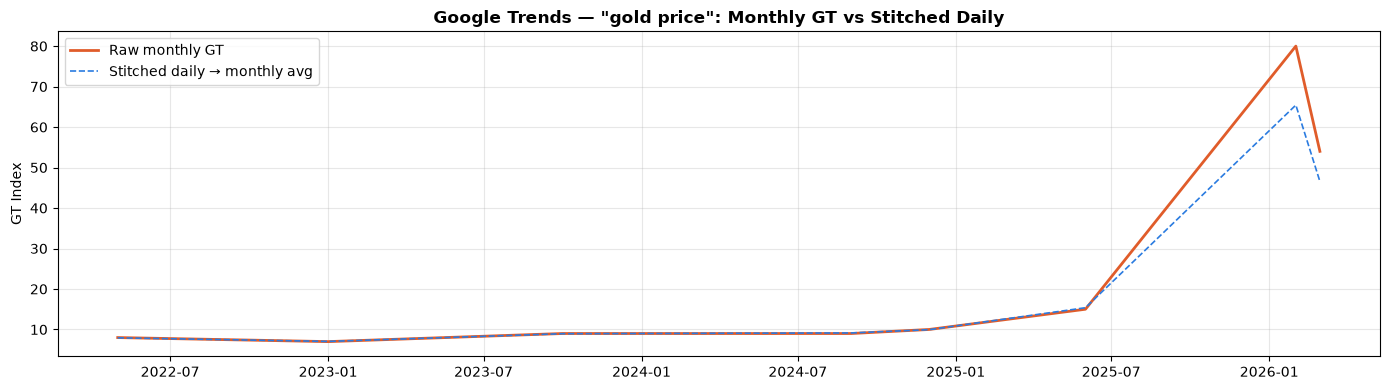

In [42]:
# Plot the series and check alignment with monthly anchor
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("C:/Python/CSUREMM/test")

# Load
daily_file   = sorted(DATA_DIR.glob("gt_stitched_2022-01-01_2026-05-31.csv"))[-1]
monthly_file = sorted(DATA_DIR.glob("gt_monthly_2022-01-01_2026-05-31.csv"))[-1]

daily   = pd.read_csv(daily_file,   parse_dates=["Time"]).set_index("Time")
monthly = pd.read_csv(monthly_file, parse_dates=["Time"]).set_index("Time")
daily.columns   = ["daily"]
monthly.columns = ["monthly"]

# Aggregate daily → month-start for apples-to-apples overlay
daily_agg = daily["daily"].resample("MS").mean().rename("daily_agg_monthly")

merged = pd.concat([monthly["monthly"], daily_agg], axis=1).dropna()

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(merged.index, merged["monthly"],           color="#E05C2A", linewidth=2,   label="Raw monthly GT")
ax.plot(merged.index, merged["daily_agg_monthly"], color="#2A7BE0", linewidth=1.2, linestyle="--", label="Stitched daily → monthly avg")
ax.set_title('Google Trends — "gold price": Monthly GT vs Stitched Daily', fontweight="bold")
ax.set_ylabel("GT Index")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig(DATA_DIR / "gt_alignment.png", dpi=150)
plt.show()

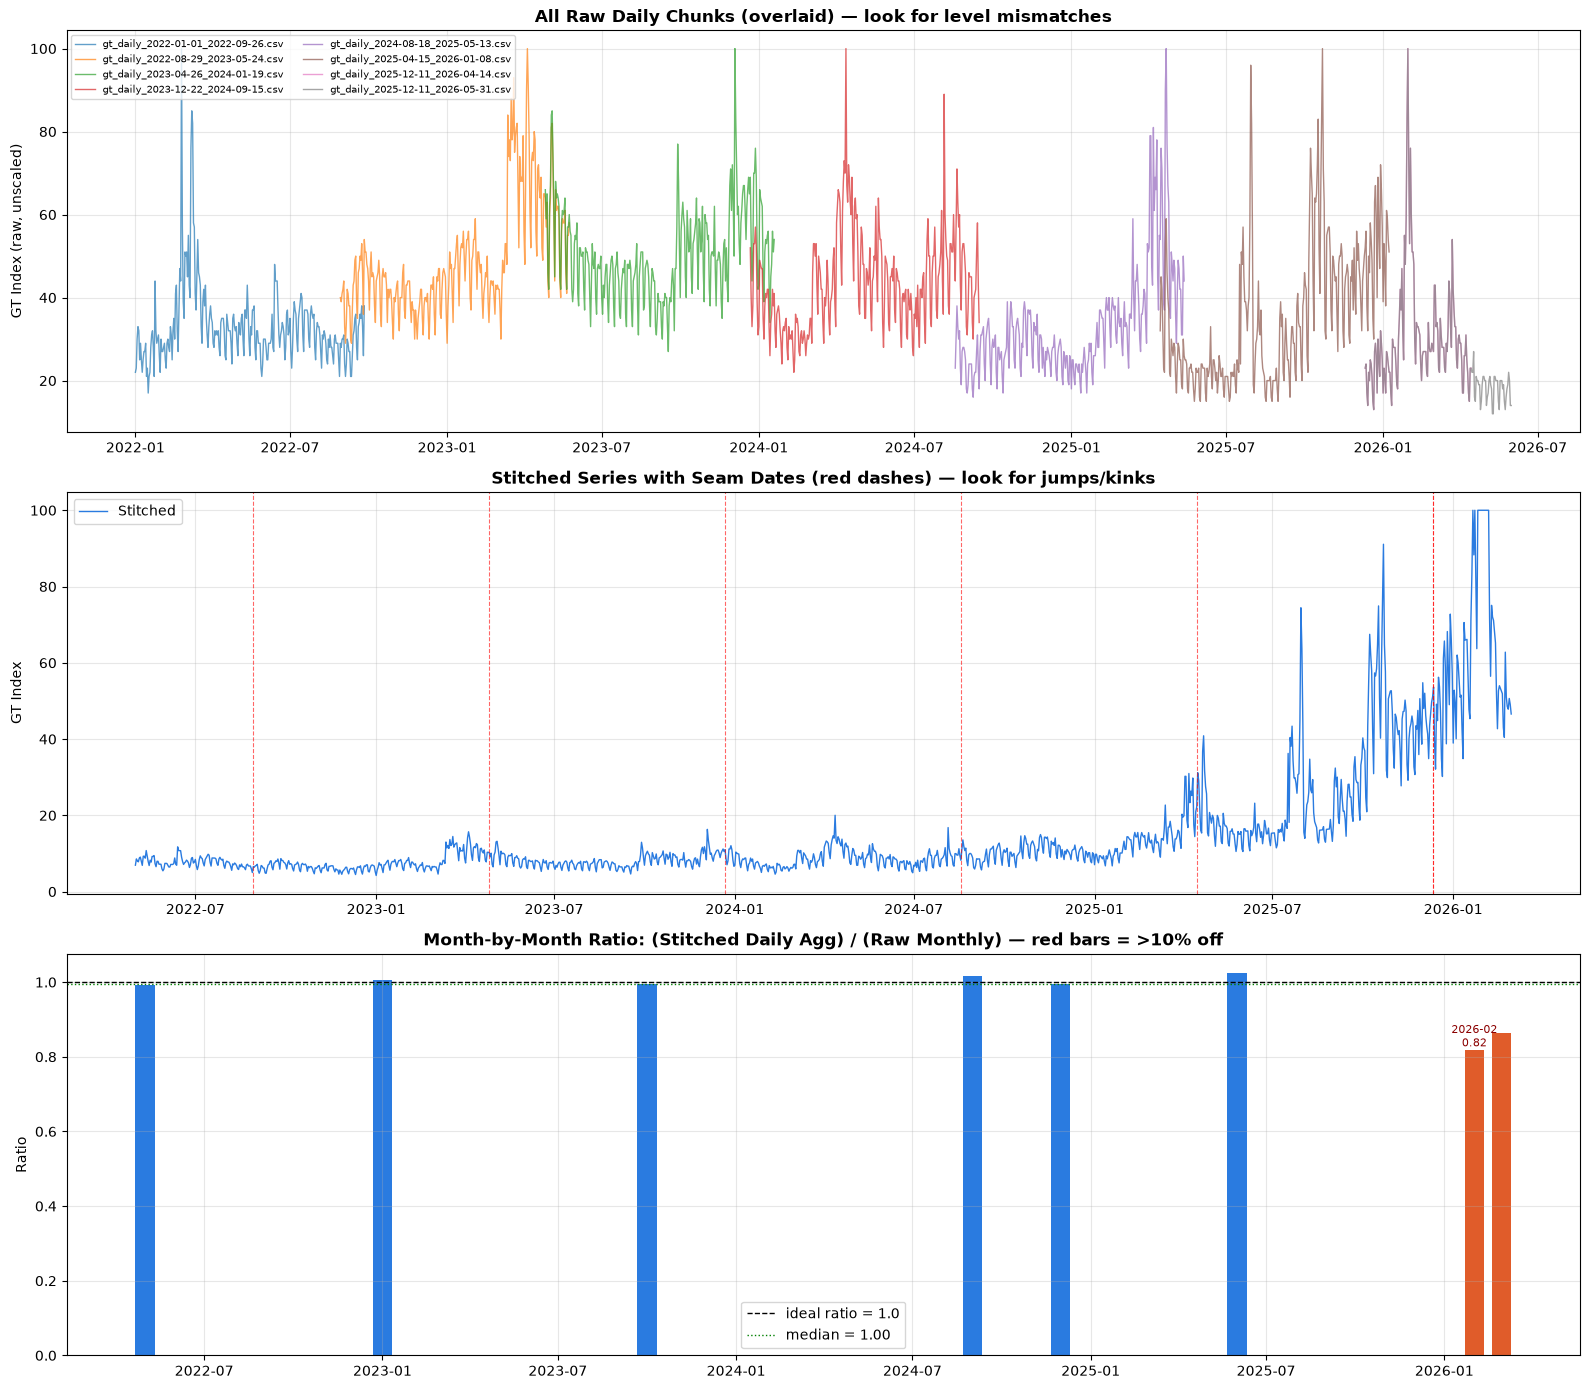


Months with ratio outside [0.85, 1.15]:
            monthly  daily_agg     ratio
Time                                    
2026-02-01     80.0  65.431251  0.817891


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("C:/Python/CSUREMM/test")

# ── 1. Load all raw daily chunks (pre-stitching) ─────────────────────────────
chunk_files = sorted(DATA_DIR.glob("gt_daily_*.csv"))

chunks = []
for f in chunk_files:
    df = pd.read_csv(f, parse_dates=["Time"])
    df.columns = ["Time", "value"]
    df["source"] = f.name          # ← this creates a column, not a scalar
    chunks.append((f.name, df))    # ← store name separately as a tuple

# ── 2. Plot all raw chunks overlaid — reveals where values diverge ────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
    
ax = axes[0]
for name, df in chunks:
    ax.plot(df["Time"], df["value"], alpha=0.7, linewidth=1, label=name)
ax.set_title("All Raw Daily Chunks (overlaid) — look for level mismatches", fontweight="bold")
ax.set_ylabel("GT Index (raw, unscaled)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

# ── 3. Seam zoom: ±45 days around each chunk boundary ────────────────────────
stitched_file = sorted(DATA_DIR.glob("gt_stitched_2022-01-01_2026-05-31.csv"))[-1]
stitched = pd.read_csv(stitched_file, parse_dates=["Time"]).set_index("Time").squeeze()

seam_dates = [pd.to_datetime(df["Time"].min()) for _, df in chunks[1:]]

ax = axes[1]
ax.plot(stitched.index, stitched.values, color="#2A7BE0", linewidth=1, label="Stitched")
for seam in seam_dates:
    ax.axvline(seam, color="red", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_title("Stitched Series with Seam Dates (red dashes) — look for jumps/kinks", fontweight="bold")
ax.set_ylabel("GT Index")
ax.legend()
ax.grid(alpha=0.3)

# ── 4. Month-by-month ratio: stitched_agg / raw_monthly ──────────────────────
monthly_file = sorted(DATA_DIR.glob("gt_monthly_*.csv"))[-1]
monthly = pd.read_csv(monthly_file, parse_dates=["Time"]).set_index("Time").squeeze()
monthly.name = "monthly"

daily_agg = stitched.resample("MS").mean()
daily_agg.name = "daily_agg"

ratio = pd.concat([monthly, daily_agg], axis=1).dropna()
ratio["ratio"] = ratio["daily_agg"] / ratio["monthly"]

ax = axes[2]
bars = ax.bar(ratio.index, ratio["ratio"], width=20,
              color=["#E05C2A" if r > 1.1 or r < 0.9 else "#2A7BE0" for r in ratio["ratio"]])
ax.axhline(1.0, color="black", linewidth=1, linestyle="--", label="ideal ratio = 1.0")
ax.axhline(ratio["ratio"].median(), color="green", linewidth=1,
           linestyle=":", label=f"median = {ratio['ratio'].median():.2f}")
ax.set_title("Month-by-Month Ratio: (Stitched Daily Agg) / (Raw Monthly) — red bars = >10% off", fontweight="bold")
ax.set_ylabel("Ratio")
ax.legend()
ax.grid(alpha=0.3)

# Annotate worst months
worst = ratio[ratio["ratio"] > 1.15].index.tolist() + ratio[ratio["ratio"] < 0.85].index.tolist()
for d in worst:
    ax.annotate(f"{d.strftime('%Y-%m')}\n{ratio.loc[d,'ratio']:.2f}",
                xy=(d, ratio.loc[d, "ratio"]), fontsize=8, color="darkred",
                ha="center", va="bottom")

plt.tight_layout()
# plt.savefig(DATA_DIR / "gt_mismatch_diagnostic.png", dpi=150)
plt.show()

# ── 5. Print the worst offending months ──────────────────────────────────────
print("\nMonths with ratio outside [0.85, 1.15]:")
print(ratio[ratio["ratio"].lt(0.85) | ratio["ratio"].gt(1.15)][["monthly", "daily_agg", "ratio"]].to_string())